In [12]:
import pandas as pd

In [13]:
df=pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [11]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


 **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [4]:
df['category'].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [5]:
df['category'].value_counts().head(5)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?


In [9]:
top_categories = df['category'].value_counts().head(10)
top_categories_lakhs = top_categories / 100000

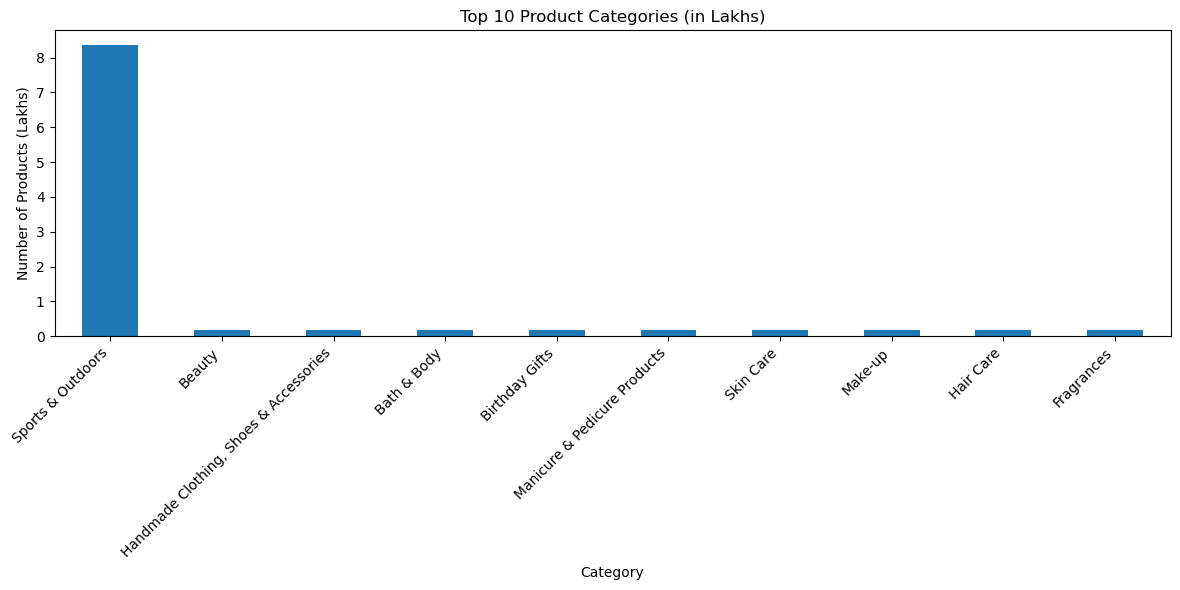

In [16]:
import matplotlib.pyplot as plt

top_categories = df['category'].value_counts().head(10) / 100000  # in lakhs

plt.figure(figsize=(12,6))  

top_categories.plot(kind='bar')

plt.title('Top 10 Product Categories (in Lakhs)')
plt.xlabel('Category')
plt.ylabel('Number of Products (Lakhs)')

plt.xticks(rotation=45, ha='right') 
plt.tight_layout()  

plt.show()

In [17]:
top5 = df['category'].value_counts().head(5)

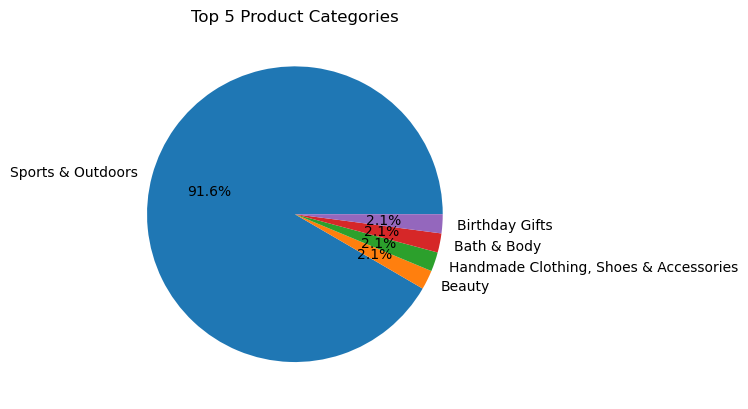

In [18]:
import matplotlib.pyplot as plt

plt.figure()

plt.pie(top5, labels=top5.index, autopct='%1.1f%%')

plt.title('Top 5 Product Categories')

plt.show()

 **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?


In [19]:
df['price'].describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [20]:
df['price'].mean()

np.float64(89.24380943923661)

In [21]:
df['price'].median()

19.09

In [25]:
df['price'].mode()

0    9.99
Name: price, dtype: float64

Average price is much higher as compared to most frequent price(mode). Some productds are high priced.

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [26]:
df['price'].var()

119445.48532256528

In [27]:
df['price'].std()

345.60886175352226

In [29]:
price_range = df['price'].max() - df['price'].min()
print(price_range)

100000.0


In [30]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print('IQR',IQR)

IQR 36.0


Price range is highly varied. Variation suggests highly spread product prices.

 **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

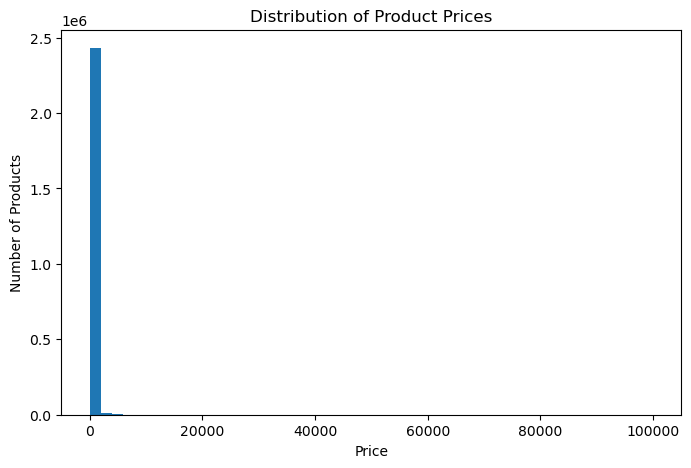

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=50)

plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Number of Products')

plt.show()

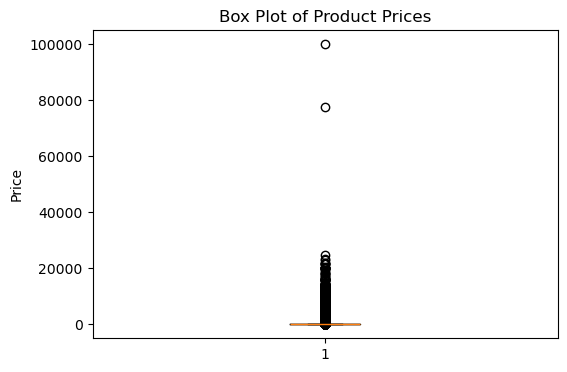

In [33]:
plt.figure(figsize=(6,4))

plt.boxplot(df['price'])

plt.title('Box Plot of Product Prices')
plt.ylabel('Price')

plt.show()

Histogram not useful as many products are in lower price range. Box plot shows presence of outliers showing some products are expensive as compared to others.

  - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

In [37]:
df['stars'].value_counts()

stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
4.8      41858
3.9      36555
3.8      27876
3.7      21137
3.6      16219
3.5      14673
3.0      12819
4.9      11081
3.4      10355
1.0       8484
3.3       8269
3.2       5771
3.1       4679
2.0       3901
2.9       3341
2.8       2306
2.7       2104
2.5       2103
2.6       1579
2.4       1060
2.3        734
2.2        602
2.1        540
1.5        404
1.9        300
1.8        249
1.7        177
1.4        149
1.6        147
1.3         78
1.2         23
1.1          3
Name: count, dtype: int64

In [34]:
df['stars'].mean()

np.float64(2.152836472966066)

In [35]:
df['stars'].median()

0.0

In [36]:
df['stars'].mode()

0    0.0
Name: stars, dtype: float64

Median and mode are coming out to be zero. Value counts also suggest that 0 rating are majority which means customers generally dont rate products.

. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

In [38]:
df['stars'].var()

4.81743402976196

In [39]:
df['stars'].std()

2.1948653785054697

In [40]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print('IQR',IQR)

IQR 36.0


It is somewaht varied. But not extreme.

**Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [41]:

skewness = df['stars'].skew()
kurtosis = df['stars'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 0.08120735761080881
Kurtosis: -1.9260061280432994


Skewness zero means normal distribution.
The kurtosis value  is negative, which shows that the distribution is flatter than a normal distribution and has fewer extreme values

**Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?


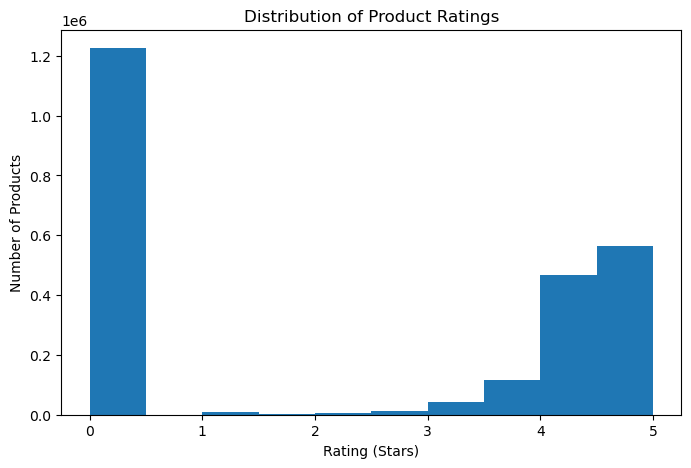

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['stars'], bins=10)

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Products')

plt.show()

Most customers have not provided rating. Among those who have provided most common are between 4 and 5